In [2]:
from google.colab import drive
import numpy as np

drive.mount('/content/drive')

SAVE_PATH = '/content/drive/MyDrive/RootKit/procesado/'

rutas_train     = np.load(SAVE_PATH + 'rutas_train.npy',     allow_pickle=True)
rutas_val       = np.load(SAVE_PATH + 'rutas_val.npy',       allow_pickle=True)
rutas_test      = np.load(SAVE_PATH + 'rutas_test.npy',      allow_pickle=True)
etiquetas_train = np.load(SAVE_PATH + 'etiquetas_train.npy', allow_pickle=True)
etiquetas_val   = np.load(SAVE_PATH + 'etiquetas_val.npy',   allow_pickle=True)
etiquetas_test  = np.load(SAVE_PATH + 'etiquetas_test.npy',  allow_pickle=True)

print(f"Train: {len(rutas_train)} | Val: {len(rutas_val)} | Test: {len(rutas_test)}")

Mounted at /content/drive
Train: 14447 | Val: 3096 | Test: 3096


In [3]:
# ============================================================
# IMPORTS
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from PIL import Image
import io
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization

from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

print(f'TensorFlow: {tf.__version__}')
print(f'GPU: {tf.config.list_physical_devices("GPU")}')

TensorFlow: 2.19.0
GPU: []


In [4]:
# ============================================================
# CONFIGURACION GLOBAL
# ============================================================
IMG_SIZE    = (128, 128)
BATCH_SIZE  = 32
NUM_CLASSES = 15
SEED        = 42

MODEL_PATH  = '/content/drive/MyDrive/RootKit/models/'

import os
os.makedirs(MODEL_PATH, exist_ok=True)

tf.random.set_seed(SEED)
np.random.seed(SEED)
print('Configuracion lista.')

Configuracion lista.


In [ ]:
# DIAGNOSTICO — correr antes de cualquier otra cosa
print("Tipo de dato en rutas_train:", type(rutas_train[0]))
print("Ejemplo:", rutas_train[0])
print()
print("Tipo de dato en etiquetas_train:", type(etiquetas_train[0]))
print("Ejemplo:", etiquetas_train[0])

Tipo de dato en rutas_train: <class 'numpy.str_'>
Ejemplo: /content/drive/MyDrive/RootKit/PlantVillage/Potato___Late_blight/2af683b8-ad55-450d-9047-630b85a2d128___RS_LB 4614.JPG

Tipo de dato en etiquetas_train: <class 'numpy.str_'>
Ejemplo: Potato___Late_blight


In [5]:
from PIL import Image
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Crear el encoder con TODAS las etiquetas posibles
le = LabelEncoder()
le.fit(np.concatenate([etiquetas_train, etiquetas_val, etiquetas_test]))

NOMBRES_CLASES = list(le.classes_)
NUM_CLASSES = len(NOMBRES_CLASES)

print(f'Clases encontradas ({NUM_CLASSES}):')
for i, nombre in enumerate(NOMBRES_CLASES):
    print(f'  {i}: {nombre}')

Clases encontradas (15):
  0: Pepper__bell___Bacterial_spot
  1: Pepper__bell___healthy
  2: Potato___Early_blight
  3: Potato___Late_blight
  4: Potato___healthy
  5: Tomato_Bacterial_spot
  6: Tomato_Early_blight
  7: Tomato_Late_blight
  8: Tomato_Leaf_Mold
  9: Tomato_Septoria_leaf_spot
  10: Tomato_Spider_mites_Two_spotted_spider_mite
  11: Tomato__Target_Spot
  12: Tomato__Tomato_YellowLeaf__Curl_Virus
  13: Tomato__Tomato_mosaic_virus
  14: Tomato_healthy


In [6]:
# ============================================================
# CARGAR IMAGENES DESDE LAS RUTAS .npy
# (rutas_train/val/test y etiquetas_train/val/test ya estan cargadas)
# ============================================================
from PIL import Image
import io

def cargar_imagenes(rutas, etiquetas, img_size=IMG_SIZE):
    X, y = [], []
    errores = 0
    # Convertir etiquetas string -> enteros
    etiquetas_num = le.transform(etiquetas)
    for ruta, etiqueta in zip(rutas, etiquetas_num):
        try:
            img = Image.open(str(ruta)).convert('RGB').resize(img_size)
            X.append(np.array(img, dtype='float32') / 255.0)
            y.append(etiqueta)
        except Exception as e:
            errores += 1
            continue
    print(f'Cargadas: {len(X)} | Saltadas por error: {errores}')
    return np.array(X, dtype='float32'), to_categorical(np.array(y), NUM_CLASSES)

print('Cargando train...')
X_train, y_train = cargar_imagenes(rutas_train, etiquetas_train)
print(f'  X_train: {X_train.shape}')

print('Cargando val...')
X_val, y_val = cargar_imagenes(rutas_val, etiquetas_val)
print(f'  X_val:   {X_val.shape}')

print('Cargando test...')
X_test, y_test = cargar_imagenes(rutas_test, etiquetas_test)
print(f'  X_test:  {X_test.shape}')

Cargando train...
Cargadas: 14446 | Saltadas por error: 1
  X_train: (14446, 128, 128, 3)
Cargando val...
Cargadas: 3096 | Saltadas por error: 0
  X_val:   (3096, 128, 128, 3)
Cargando test...
Cargadas: 3096 | Saltadas por error: 0
  X_test:  (3096, 128, 128, 3)


## CNN v1 — Modelo Base

Arquitectura base sin regularizacion, disenada como punto de partida para evaluar el rendimiento inicial del modelo sobre el dataset PlantVillage.

**Implementa:**
- 3 bloques Conv2D (32, 64, 128 filtros) + MaxPooling2D
- Capa densa de 256 neuronas con Dropout(0.3)
- Optimizador Adam con lr=1e-3
- EarlyStopping con patience=5 y min_delta=0.001

**Resultado:** 91.47% de accuracy en validacion (11 epochs)

**Diferencias con versiones posteriores:**
- Sin BatchNormalization, entrenamiento menos estable
- Dropout mas bajo (0.3), mayor riesgo de overfitting
- Sin data augmentation, entrena solo con imagenes originales
- Arquitectura mas ligera y rapida de entrenar

In [ ]:
# ============================================================
# ARQUITECTURA CNN BASE
# Conv2D(32) -> MaxPool -> Conv2D(64) -> MaxPool -> Conv2D(128) -> MaxPool
# -> Flatten -> Dense(256) -> Dropout -> Dense(15, softmax)
# ============================================================
def construir_cnn_v1(input_shape=(128, 128, 3), num_classes=15):
    model = Sequential(name='CNN_PlantVillage_v1')

    model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape))
    model.add(MaxPooling2D((2,2)))

    model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2,2)))

    model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2,2)))

    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

modelo_v1 = construir_cnn_v1(input_shape=(*IMG_SIZE, 3), num_classes=NUM_CLASSES)
modelo_v1.summary()

Model: "CNN_PlantVillage_v1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,485,967 (32.37 MB)

 Trainable params: 8,485,967 (32.37 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# PRIMERA EPOCH DE PRUEBA — verificar pipeline
# ============================================================
historia_prueba = modelo_v1.fit(
    X_train, y_train,
    epochs=1,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    verbose=1
)

print('\n Pipeline OK — primera epoch sin errores.')
print(f'   Train acc: {historia_prueba.history["accuracy"][0]:.4f}')
print(f'   Val   acc: {historia_prueba.history["val_accuracy"][0]:.4f}')

452/452 ━━━━━━━━━━━━━━━━━━━━ 590s 1s/step - accuracy: 0.5941 - loss: 1.2700 - val_accuracy: 0.8036 - val_loss: 0.6121

 Pipeline OK — primera epoch sin errores.
   Train acc: 0.5941
   Val   acc: 0.8036


In [ ]:
# ============================================================
# CALLBACKS PARA CNN v1
# ============================================================
callbacks_v1 = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        min_delta=0.001,          # mejora minima significativa
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=MODEL_PATH + 'best_cnn_v1.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# ============================================================
# ENTRENAMIENTO CNN v1 CON EARLYSTOPPING
# ============================================================
modelo_v1 = construir_cnn_v1(input_shape=(*IMG_SIZE, 3), num_classes=NUM_CLASSES)

historia_v1 = modelo_v1.fit(
    X_train, y_train,
    epochs=50,                    # maximo 50, EarlyStopping detendra antes
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=callbacks_v1,
    verbose=1
)

print(f'\n Entrenamiento v1 completado.')
print(f'Epochs ejecutadas: {len(historia_v1.history["accuracy"])} de 50')

Epoch 1/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4439 - loss: 1.7186
Epoch 1: val_accuracy improved from None to 0.76550, saving model to /content/drive/MyDrive/RootKit/models/best_cnn_v1.h5



Epoch 1: finished saving model to /content/drive/MyDrive/RootKit/models/best_cnn_v1.h5
452/452 ━━━━━━━━━━━━━━━━━━━━ 600s 1s/step - accuracy: 0.5993 - loss: 1.2343 - val_accuracy: 0.7655 - val_loss: 0.7051
Epoch 2/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7899 - loss: 0.6364
Epoch 2: val_accuracy improved from 0.76550 to 0.85950, saving model to /content/drive/MyDrive/RootKit/models/best_cnn_v1.h5



Epoch 2: finished saving model to /content/drive/MyDrive/RootKit/models/best_cnn_v1.h5
452/452 ━━━━━━━━━━━━━━━━━━━━ 620s 1s/step - accuracy: 0.8063 - loss: 0.5868 - val_accuracy: 0.8595 - val_loss: 0.4269
Epoch 3/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8587 - loss: 0.4241
Epoch 3: val_accuracy did not improve from 0.85950
452/452 ━━━━━━━━━━━━━━━━━━━━ 599s 1s/step - accuracy: 0.8667 - loss: 0.3952 - val_accuracy: 0.8366 - val_loss: 0.4947
Epoch 4/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8695 - loss: 0.3718
Epoch 4: val_accuracy improved from 0.85950 to 0.89244, saving model to /content/drive/MyDrive/RootKit/models/best_cnn_v1.h5



Epoch 4: finished saving model to /content/drive/MyDrive/RootKit/models/best_cnn_v1.h5
452/452 ━━━━━━━━━━━━━━━━━━━━ 593s 1s/step - accuracy: 0.8926 - loss: 0.3070 - val_accuracy: 0.8924 - val_loss: 0.3170
Epoch 5/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9111 - loss: 0.2509
Epoch 5: val_accuracy did not improve from 0.89244
452/452 ━━━━━━━━━━━━━━━━━━━━ 596s 1s/step - accuracy: 0.9177 - loss: 0.2374 - val_accuracy: 0.8911 - val_loss: 0.3254
Epoch 6/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9293 - loss: 0.2129
Epoch 6: val_accuracy improved from 0.89244 to 0.91473, saving model to /content/drive/MyDrive/RootKit/models/best_cnn_v1.h5



Epoch 6: finished saving model to /content/drive/MyDrive/RootKit/models/best_cnn_v1.h5
452/452 ━━━━━━━━━━━━━━━━━━━━ 596s 1s/step - accuracy: 0.9358 - loss: 0.1938 - val_accuracy: 0.9147 - val_loss: 0.2690
Epoch 7/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9476 - loss: 0.1506
Epoch 7: val_accuracy did not improve from 0.91473
452/452 ━━━━━━━━━━━━━━━━━━━━ 586s 1s/step - accuracy: 0.9497 - loss: 0.1431 - val_accuracy: 0.9115 - val_loss: 0.2822
Epoch 8/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9577 - loss: 0.1280
Epoch 8: val_accuracy did not improve from 0.91473
452/452 ━━━━━━━━━━━━━━━━━━━━ 632s 1s/step - accuracy: 0.9541 - loss: 0.1350 - val_accuracy: 0.9138 - val_loss: 0.3070
Epoch 9/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9635 - loss: 0.1074
Epoch 9: val_accuracy did not improve from 0.91473
452/452 ━━━━━━━━━━━━━━━━━━━━ 621s 1s/step - accuracy: 0.9634 - loss: 0.1098 - val_accuracy: 0.8931 - val_loss: 0.3492
Epoch 10/50
452/452 ━━━━━━━━━━━━

Guardado: /content/drive/MyDrive/RootKit/procesado/curvas_cnn_v1.png


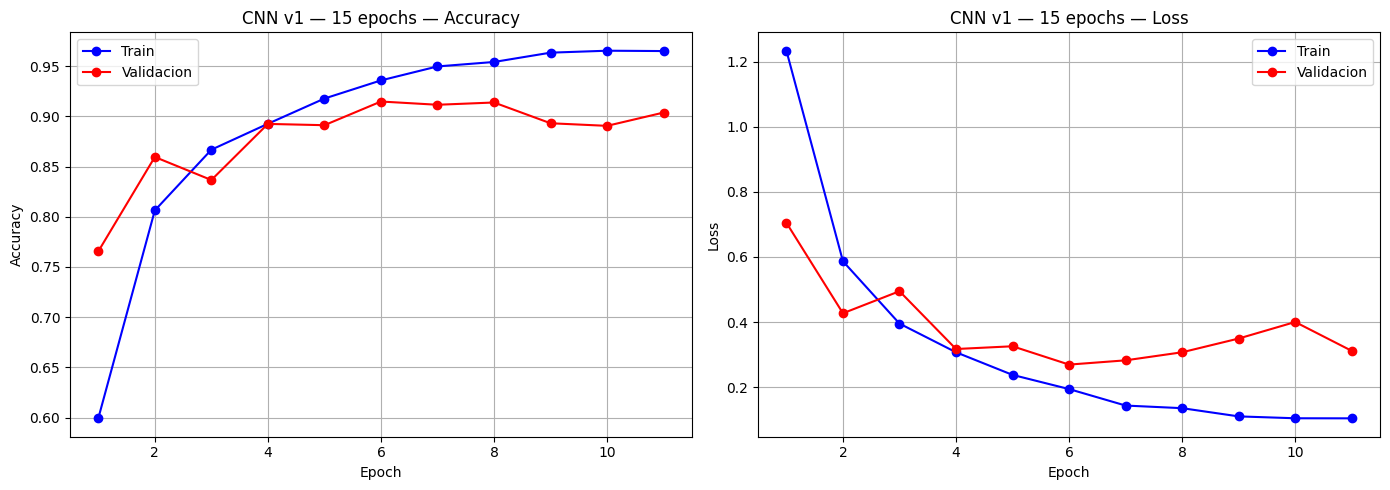

In [ ]:
# ============================================================
# CURVAS DE ACCURACY Y LOSS — train vs validation
# ============================================================
def graficar_historia(historia, titulo='CNN', guardar_en=None):
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(historia.history['accuracy']) + 1)

    axs[0].plot(epochs, historia.history['accuracy'],     'b-o', label='Train')
    axs[0].plot(epochs, historia.history['val_accuracy'], 'r-o', label='Validacion')
    axs[0].set_title(f'{titulo} — Accuracy')
    axs[0].set_xlabel('Epoch'); axs[0].set_ylabel('Accuracy')
    axs[0].legend(); axs[0].grid(True)

    axs[1].plot(epochs, historia.history['loss'],     'b-o', label='Train')
    axs[1].plot(epochs, historia.history['val_loss'], 'r-o', label='Validacion')
    axs[1].set_title(f'{titulo} — Loss')
    axs[1].set_xlabel('Epoch'); axs[1].set_ylabel('Loss')
    axs[1].legend(); axs[1].grid(True)

    plt.tight_layout()
    if guardar_en:
        plt.savefig(guardar_en, dpi=150, bbox_inches='tight')
        print(f'Guardado: {guardar_en}')
    plt.show()

graficar_historia(
    historia_v1,
    titulo='CNN v1 — 15 epochs',
    guardar_en=SAVE_PATH + 'curvas_cnn_v1.png'
)

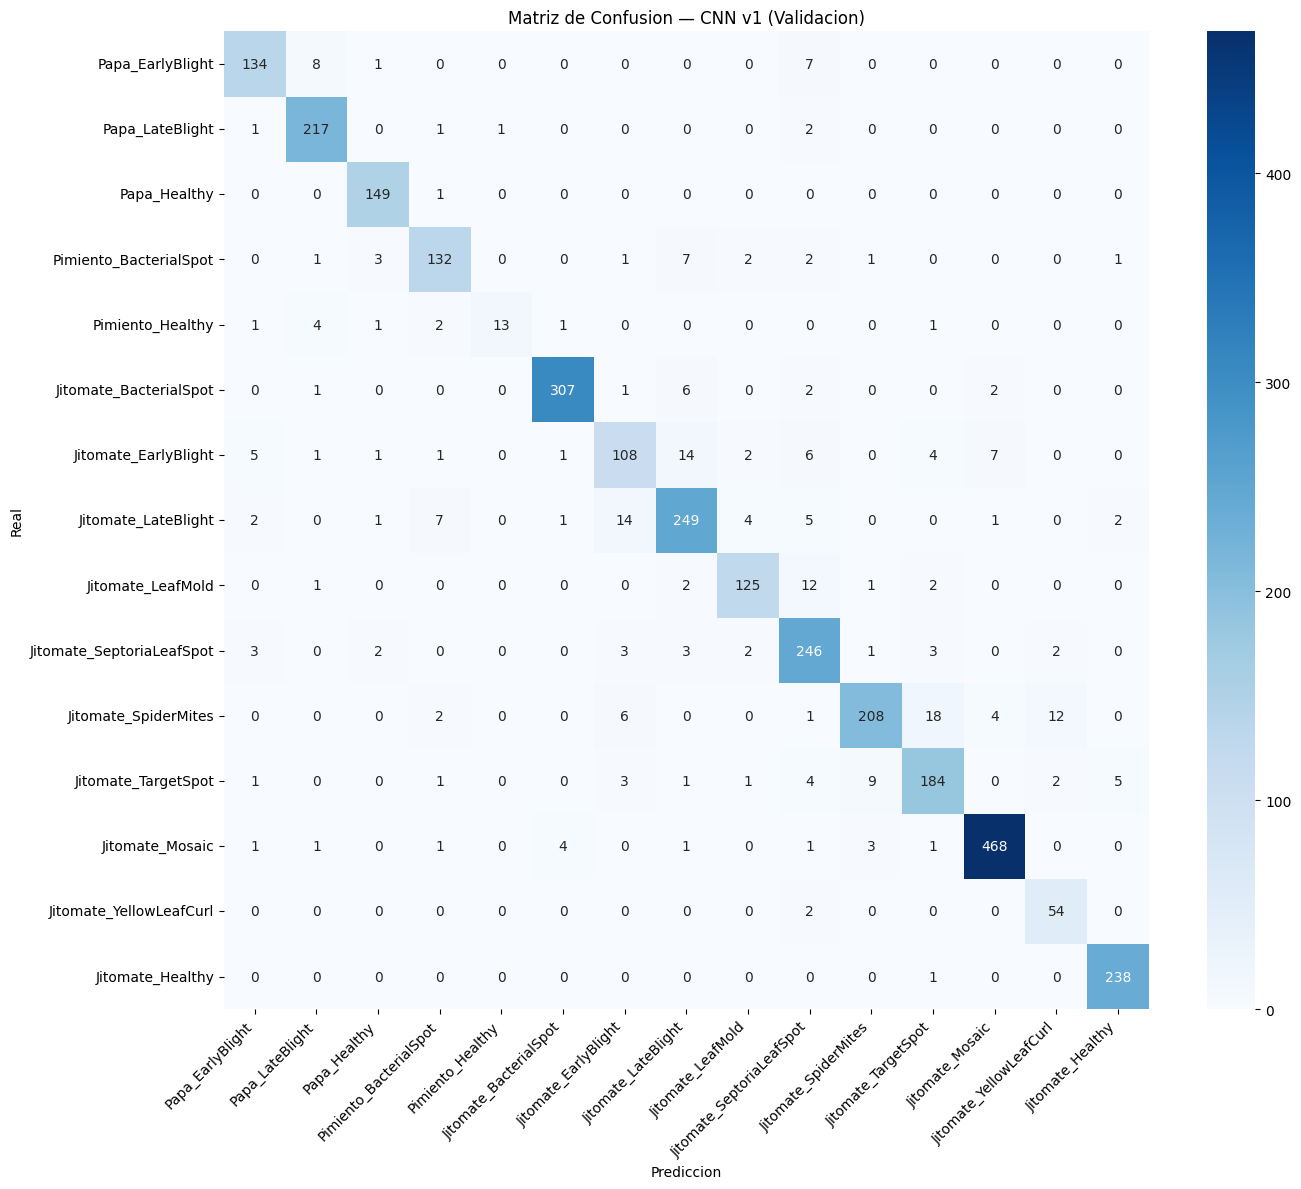

In [ ]:
# ============================================================
# MATRIZ DE CONFUSION — set de validacion
# ============================================================
# Ajusta esta lista al orden real de clases en tu dataset
NOMBRES_CLASES = [
    'Papa_EarlyBlight', 'Papa_LateBlight', 'Papa_Healthy',
    'Pimiento_BacterialSpot', 'Pimiento_Healthy',
    'Jitomate_BacterialSpot', 'Jitomate_EarlyBlight',
    'Jitomate_LateBlight', 'Jitomate_LeafMold',
    'Jitomate_SeptoriaLeafSpot', 'Jitomate_SpiderMites',
    'Jitomate_TargetSpot', 'Jitomate_Mosaic',
    'Jitomate_YellowLeafCurl', 'Jitomate_Healthy'
]

y_pred_v1 = np.argmax(modelo_v1.predict(X_val, verbose=0), axis=1)
y_true_val = np.argmax(y_val, axis=1)

cm_v1 = confusion_matrix(y_true_val, y_pred_v1)

plt.figure(figsize=(14, 12))
sns.heatmap(cm_v1, annot=True, fmt='d', cmap='Blues',
            xticklabels=NOMBRES_CLASES, yticklabels=NOMBRES_CLASES)
plt.title('Matriz de Confusion — CNN v1 (Validacion)')
plt.xlabel('Prediccion'); plt.ylabel('Real')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(SAVE_PATH + 'confusion_matrix_v1.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# REPORTE DE CLASIFICACION v1
# ============================================================
print('=== REPORTE CNN v1 (Validacion) ===')
print(classification_report(y_true_val, y_pred_v1, target_names=NOMBRES_CLASES))

acc_v1 = accuracy_score(y_true_val, y_pred_v1)
print(f'Accuracy global: {acc_v1:.4f} ({acc_v1*100:.2f}%)')

=== REPORTE CNN v1 (Validacion) ===
                           precision    recall  f1-score   support

         Papa_EarlyBlight       0.91      0.89      0.90       150
          Papa_LateBlight       0.93      0.98      0.95       222
             Papa_Healthy       0.94      0.99      0.97       150
   Pimiento_BacterialSpot       0.89      0.88      0.89       150
         Pimiento_Healthy       0.93      0.57      0.70        23
   Jitomate_BacterialSpot       0.98      0.96      0.97       319
     Jitomate_EarlyBlight       0.79      0.72      0.76       150
      Jitomate_LateBlight       0.88      0.87      0.88       286
        Jitomate_LeafMold       0.92      0.87      0.90       143
Jitomate_SeptoriaLeafSpot       0.85      0.93      0.89       265
     Jitomate_SpiderMites       0.93      0.83      0.88       251
      Jitomate_TargetSpot       0.86      0.87      0.87       211
          Jitomate_Mosaic       0.97      0.97      0.97       481
  Jitomate_YellowLeafCurl

In [ ]:
# ============================================================
# DIAGNOSTICO: OVERFITTING / UNDERFITTING
# ============================================================
train_acc = historia_v1.history['accuracy'][-1]
val_acc   = historia_v1.history['val_accuracy'][-1]
diff      = train_acc - val_acc

print(f'Train acc (ep. final): {train_acc:.4f}')
print(f'Val   acc (ep. final): {val_acc:.4f}')
print(f'Diferencia:            {diff:.4f}')
print()

if train_acc < 0.60 and val_acc < 0.60:
    print(' UNDERFITTING — modelo no aprende suficiente.')
    print('   -> Mas epochs, modelo mas profundo o ajustar lr.')
elif diff > 0.15:
    print(' OVERFITTING — memoriza train, no generaliza.')
    print('   -> Dropout mayor, BatchNorm, Data Augmentation.')
else:
    print(' BUEN AJUSTE — train y val cercanos.')


Train acc (ep. final): 0.9650
Val   acc (ep. final): 0.9037
Diferencia:            0.0612

 BUEN AJUSTE — train y val cercanos.


In [ ]:
# ============================================================
# GUARDAR MODELO v1
# ============================================================
modelo_v1.save(MODEL_PATH + 'cnn_v1.h5')
print(f' cnn_v1.h5 guardado en {MODEL_PATH}')

 cnn_v1.h5 guardado en /content/drive/MyDrive/RootKit/models/


## CNN v2 — BatchNorm + Data Augmentation

Segunda version con regularizacion mas solida y aumento de datos para mejorar la generalizacion del modelo.

**Implementa:**
- 4 bloques Conv2D (32, 64, 128, 256 filtros) + MaxPooling2D
- BatchNormalization despues de cada bloque convolucional
- Capas densas de 512 y 256 neuronas con Dropout(0.4)
- Data augmentation: rotacion, zoom, flip horizontal, desplazamientos
- ReduceLROnPlateau, EarlyStopping y ModelCheckpoint

**Resultado:** 94.96% de accuracy en validacion (30 epochs)

**Diferencias con v1 y v3:**
- Agrega un bloque convolucional extra (256 filtros) respecto a v1
- BatchNormalization que v1 no tiene
- Data augmentation mas agresivo que v3 (rotation=20, shear=0.1)
- Learning rate inicial alto (1e-3) que causo inestabilidad en las curvas de validacion#


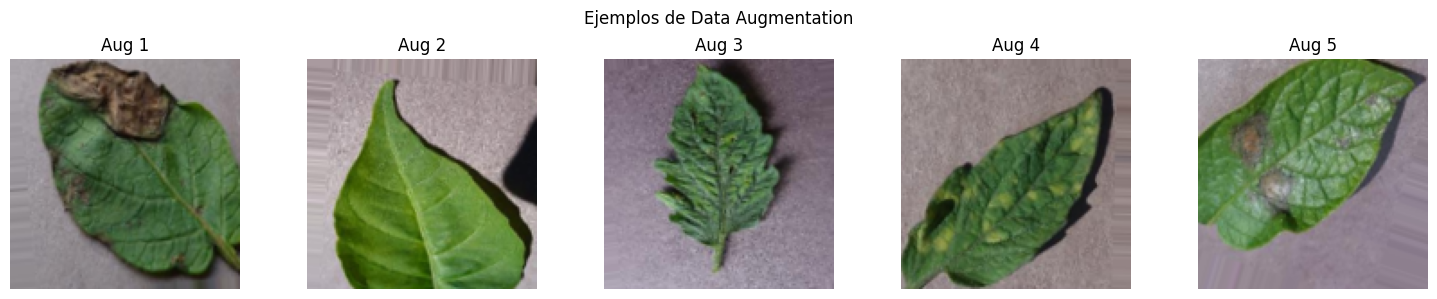

Data augmentation configurado.


In [ ]:
# ============================================================
# DATA AUGMENTATION — corregido
# ============================================================
datagen_train = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
    # SIN brightness_range aqui — causa valores fuera de [0,1] con imagenes ya normalizadas
)

# Vista previa correcta: tomar imagen original (sin normalizar), augmentar, luego mostrar
fig, axs = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    # Imagen en rango [0,255] para augmentar y mostrar correctamente
    img_original = (X_train[i] * 255).astype('uint8')
    aug = next(datagen_train.flow(
        img_original[np.newaxis],  # shape (1, 128, 128, 3)
        batch_size=1
    ))[0].astype('uint8')
    axs[i].imshow(aug)
    axs[i].axis('off')
    axs[i].set_title(f'Aug {i+1}')
plt.suptitle('Ejemplos de Data Augmentation')
plt.tight_layout()
plt.show()
print('Data augmentation configurado.')

In [ ]:
# ============================================================
# ARQUITECTURA CNN v2 CON EARLYSTOPPING
# BatchNorm + Dropout(0.4) + bloque extra Conv2D(256)
# ============================================================
def construir_cnn_v2(input_shape=(128, 128, 3), num_classes=NUM_CLASSES, dropout=0.4):
    model = Sequential(name='CNN_PlantVillage_v2')

    # Bloque 1
    model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))

    # Bloque 2
    model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))

    # Bloque 3
    model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))

    # Bloque 4
    model.add(Conv2D(256, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))

    # Clasificador
    model.add(Flatten())
    model.add(Dense(512, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(dropout))
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(dropout * 0.75))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

modelo_v2 = construir_cnn_v2(input_shape=(*IMG_SIZE, 3), num_classes=NUM_CLASSES)
modelo_v2.summary()

Model: "CNN_PlantVillage_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,916,687 (34.01 MB)

 Trainable params: 8,914,703 (34.01 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [ ]:
# ============================================================
# CALLBACKS
# ReduceLROnPlateau — baja el lr si val_loss no mejora en 3 epochs
# EarlyStopping     — detiene si val_loss no mejora en 7 epochs
# ModelCheckpoint   — guarda automaticamente el mejor modelo
# ============================================================
callbacks = [
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,       # divide lr a la mitad
        patience=3,       # espera 3 epochs sin mejora
        min_lr=1e-6,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=7,               # detiene si no mejora en 7 epochs
        min_delta=0.001,          # mejora minima que cuenta como "significativa"
        restore_best_weights=True,# vuelve al mejor estado automaticamente
        verbose=1
    ),
    ModelCheckpoint(
        filepath=MODEL_PATH + 'best_cnn_v2.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]
print('Callbacks listos.')

Callbacks listos.


In [ ]:
# ============================================================
# ENTRENAMIENTO v2 CON DATA AUGMENTATION
# Las imagenes del datagen deben estar en [0,1] para el modelo
# ============================================================

# Datagen trabaja sobre X_train que ya esta en [0,1] — correcto para el modelo
historia_v2 = modelo_v2.fit(
    datagen_train.flow(X_train, y_train, batch_size=BATCH_SIZE),
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    epochs=30,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

print('\n Entrenamiento v2 completado.')
print(f'Epochs ejecutadas: {len(historia_v2.history["accuracy"])}')

Epoch 1/30
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5386 - loss: 1.5443
Epoch 1: val_accuracy improved from None to 0.37532, saving model to /content/drive/MyDrive/RootKit/models/best_cnn_v2.h5



Epoch 1: finished saving model to /content/drive/MyDrive/RootKit/models/best_cnn_v2.h5
451/451 ━━━━━━━━━━━━━━━━━━━━ 1167s 3s/step - accuracy: 0.6286 - loss: 1.1867 - val_accuracy: 0.3753 - val_loss: 2.8015 - learning_rate: 0.0010
Epoch 2/30
  1/451 ━━━━━━━━━━━━━━━━━━━━ 19:11 3s/step - accuracy: 0.7500 - loss: 0.5436
Epoch 2: val_accuracy did not improve from 0.37532
451/451 ━━━━━━━━━━━━━━━━━━━━ 50s 104ms/step - accuracy: 0.7500 - loss: 0.5436 - val_accuracy: 0.3414 - val_loss: 3.1804 - learning_rate: 0.0010
Epoch 3/30
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7621 - loss: 0.7244
Epoch 3: val_accuracy did not improve from 0.37532
451/451 ━━━━━━━━━━━━━━━━━━━━ 1114s 2s/step - accuracy: 0.7785 - loss: 0.6730 - val_accuracy: 0.3592 - val_loss: 5.0121 - learning_rate: 0.0010
Epoch 4/30
  1/451 ━━━━━━━━━━━━━━━━━━━━ 14:04 2s/step - accuracy: 0.7500 - loss: 0.5802
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 4: val_accuracy did not improve from


Epoch 5: finished saving model to /content/drive/MyDrive/RootKit/models/best_cnn_v2.h5
451/451 ━━━━━━━━━━━━━━━━━━━━ 1081s 2s/step - accuracy: 0.8615 - loss: 0.4124 - val_accuracy: 0.6886 - val_loss: 1.2302 - learning_rate: 5.0000e-04
Epoch 6/30
  1/451 ━━━━━━━━━━━━━━━━━━━━ 16:25 2s/step - accuracy: 0.8750 - loss: 0.2413
Epoch 6: val_accuracy did not improve from 0.68863
451/451 ━━━━━━━━━━━━━━━━━━━━ 49s 104ms/step - accuracy: 0.8750 - loss: 0.2413 - val_accuracy: 0.6764 - val_loss: 1.3008 - learning_rate: 5.0000e-04
Epoch 7/30
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8934 - loss: 0.3270
Epoch 7: val_accuracy improved from 0.68863 to 0.82978, saving model to /content/drive/MyDrive/RootKit/models/best_cnn_v2.h5



Epoch 7: finished saving model to /content/drive/MyDrive/RootKit/models/best_cnn_v2.h5
451/451 ━━━━━━━━━━━━━━━━━━━━ 1081s 2s/step - accuracy: 0.8939 - loss: 0.3216 - val_accuracy: 0.8298 - val_loss: 0.5118 - learning_rate: 5.0000e-04
Epoch 8/30
  1/451 ━━━━━━━━━━━━━━━━━━━━ 21:40 3s/step - accuracy: 0.9375 - loss: 0.1826
Epoch 8: val_accuracy improved from 0.82978 to 0.83721, saving model to /content/drive/MyDrive/RootKit/models/best_cnn_v2.h5



Epoch 8: finished saving model to /content/drive/MyDrive/RootKit/models/best_cnn_v2.h5
451/451 ━━━━━━━━━━━━━━━━━━━━ 87s 186ms/step - accuracy: 0.9375 - loss: 0.1826 - val_accuracy: 0.8372 - val_loss: 0.5053 - learning_rate: 5.0000e-04
Epoch 9/30
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9056 - loss: 0.2848
Epoch 9: val_accuracy did not improve from 0.83721
451/451 ━━━━━━━━━━━━━━━━━━━━ 1124s 2s/step - accuracy: 0.9063 - loss: 0.2818 - val_accuracy: 0.5807 - val_loss: 2.0267 - learning_rate: 5.0000e-04
Epoch 10/30
  1/451 ━━━━━━━━━━━━━━━━━━━━ 23:07 3s/step - accuracy: 0.9375 - loss: 0.1958
Epoch 10: val_accuracy did not improve from 0.83721
451/451 ━━━━━━━━━━━━━━━━━━━━ 46s 96ms/step - accuracy: 0.9375 - loss: 0.1958 - val_accuracy: 0.5588 - val_loss: 2.1801 - learning_rate: 5.0000e-04
Epoch 11/30
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9128 - loss: 0.2650
Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 11: val_accuracy did no


Epoch 13: finished saving model to /content/drive/MyDrive/RootKit/models/best_cnn_v2.h5
451/451 ━━━━━━━━━━━━━━━━━━━━ 1122s 2s/step - accuracy: 0.9343 - loss: 0.1938 - val_accuracy: 0.8837 - val_loss: 0.3632 - learning_rate: 2.5000e-04
Epoch 14/30
  1/451 ━━━━━━━━━━━━━━━━━━━━ 21:39 3s/step - accuracy: 0.8750 - loss: 0.3194
Epoch 14: val_accuracy did not improve from 0.88372
451/451 ━━━━━━━━━━━━━━━━━━━━ 85s 182ms/step - accuracy: 0.8750 - loss: 0.3194 - val_accuracy: 0.8795 - val_loss: 0.3704 - learning_rate: 2.5000e-04
Epoch 15/30
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9478 - loss: 0.1584
Epoch 15: val_accuracy did not improve from 0.88372
451/451 ━━━━━━━━━━━━━━━━━━━━ 1116s 2s/step - accuracy: 0.9481 - loss: 0.1544 - val_accuracy: 0.8834 - val_loss: 0.4860 - learning_rate: 2.5000e-04
Epoch 16/30
  1/451 ━━━━━━━━━━━━━━━━━━━━ 14:35 2s/step - accuracy: 1.0000 - loss: 0.0324
Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 16: val_accuracy 


Epoch 17: finished saving model to /content/drive/MyDrive/RootKit/models/best_cnn_v2.h5
451/451 ━━━━━━━━━━━━━━━━━━━━ 1083s 2s/step - accuracy: 0.9573 - loss: 0.1235 - val_accuracy: 0.8986 - val_loss: 0.3452 - learning_rate: 1.2500e-04
Epoch 18/30
  1/451 ━━━━━━━━━━━━━━━━━━━━ 17:24 2s/step - accuracy: 0.9688 - loss: 0.0667
Epoch 18: val_accuracy improved from 0.89858 to 0.90633, saving model to /content/drive/MyDrive/RootKit/models/best_cnn_v2.h5



Epoch 18: finished saving model to /content/drive/MyDrive/RootKit/models/best_cnn_v2.h5
451/451 ━━━━━━━━━━━━━━━━━━━━ 51s 108ms/step - accuracy: 0.9688 - loss: 0.0667 - val_accuracy: 0.9063 - val_loss: 0.3173 - learning_rate: 1.2500e-04
Epoch 19/30
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9621 - loss: 0.1161
Epoch 19: val_accuracy did not improve from 0.90633
451/451 ━━━━━━━━━━━━━━━━━━━━ 1082s 2s/step - accuracy: 0.9591 - loss: 0.1197 - val_accuracy: 0.6951 - val_loss: 2.0657 - learning_rate: 1.2500e-04
Epoch 20/30
  1/451 ━━━━━━━━━━━━━━━━━━━━ 23:21 3s/step - accuracy: 0.9375 - loss: 0.2158
Epoch 20: val_accuracy did not improve from 0.90633
451/451 ━━━━━━━━━━━━━━━━━━━━ 85s 182ms/step - accuracy: 0.9375 - loss: 0.2158 - val_accuracy: 0.7093 - val_loss: 1.9153 - learning_rate: 1.2500e-04
Epoch 21/30
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9655 - loss: 0.1024
Epoch 21: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 21: val_accuracy did


Epoch 23: finished saving model to /content/drive/MyDrive/RootKit/models/best_cnn_v2.h5
451/451 ━━━━━━━━━━━━━━━━━━━━ 1085s 2s/step - accuracy: 0.9721 - loss: 0.0873 - val_accuracy: 0.9496 - val_loss: 0.1390 - learning_rate: 6.2500e-05
Epoch 24/30
  1/451 ━━━━━━━━━━━━━━━━━━━━ 14:33 2s/step - accuracy: 0.9375 - loss: 0.0650
Epoch 24: val_accuracy did not improve from 0.94961
451/451 ━━━━━━━━━━━━━━━━━━━━ 84s 182ms/step - accuracy: 0.9375 - loss: 0.0650 - val_accuracy: 0.9490 - val_loss: 0.1392 - learning_rate: 6.2500e-05
Epoch 25/30
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9721 - loss: 0.0812
Epoch 25: val_accuracy did not improve from 0.94961
451/451 ━━━━━━━━━━━━━━━━━━━━ 1089s 2s/step - accuracy: 0.9725 - loss: 0.0817 - val_accuracy: 0.9193 - val_loss: 0.3431 - learning_rate: 6.2500e-05
Epoch 26/30
  1/451 ━━━━━━━━━━━━━━━━━━━━ 16:15 2s/step - accuracy: 1.0000 - loss: 0.0241
Epoch 26: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 26: val_accuracy 

Guardado: /content/drive/MyDrive/RootKit/procesado/curvas_cnn_v2.png


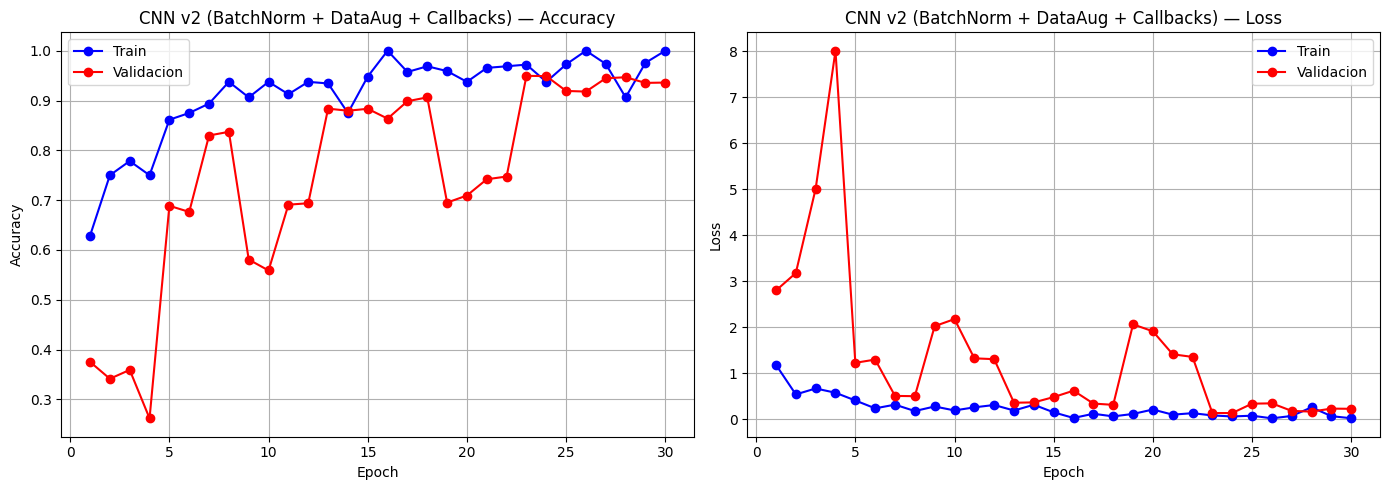

=== COMPARACION ===
CNN v1  ->  Val accuracy: 91.47%
CNN v2  ->  Val accuracy: 94.96%
Mejora: +3.49%

 META ALCANZADA: val accuracy >= 85%


In [ ]:
# ============================================================
# COMPARACION v1 vs v2
# ============================================================
graficar_historia(historia_v2,
                  titulo='CNN v2 (BatchNorm + DataAug + Callbacks)',
                  guardar_en=SAVE_PATH + 'curvas_cnn_v2.png')

_, acc_v1_eval = modelo_v1.evaluate(X_val, y_val, verbose=0)
_, acc_v2_eval = modelo_v2.evaluate(X_val, y_val, verbose=0)

print('=== COMPARACION ===')
print(f'CNN v1  ->  Val accuracy: {acc_v1_eval*100:.2f}%')
print(f'CNN v2  ->  Val accuracy: {acc_v2_eval*100:.2f}%')
print(f'Mejora: +{(acc_v2_eval - acc_v1_eval)*100:.2f}%')

if acc_v2_eval >= 0.85:
    print('\n META ALCANZADA: val accuracy >= 85%')
else:
    print(f'\n Faltan {(0.85 - acc_v2_eval)*100:.2f}% para la meta.')

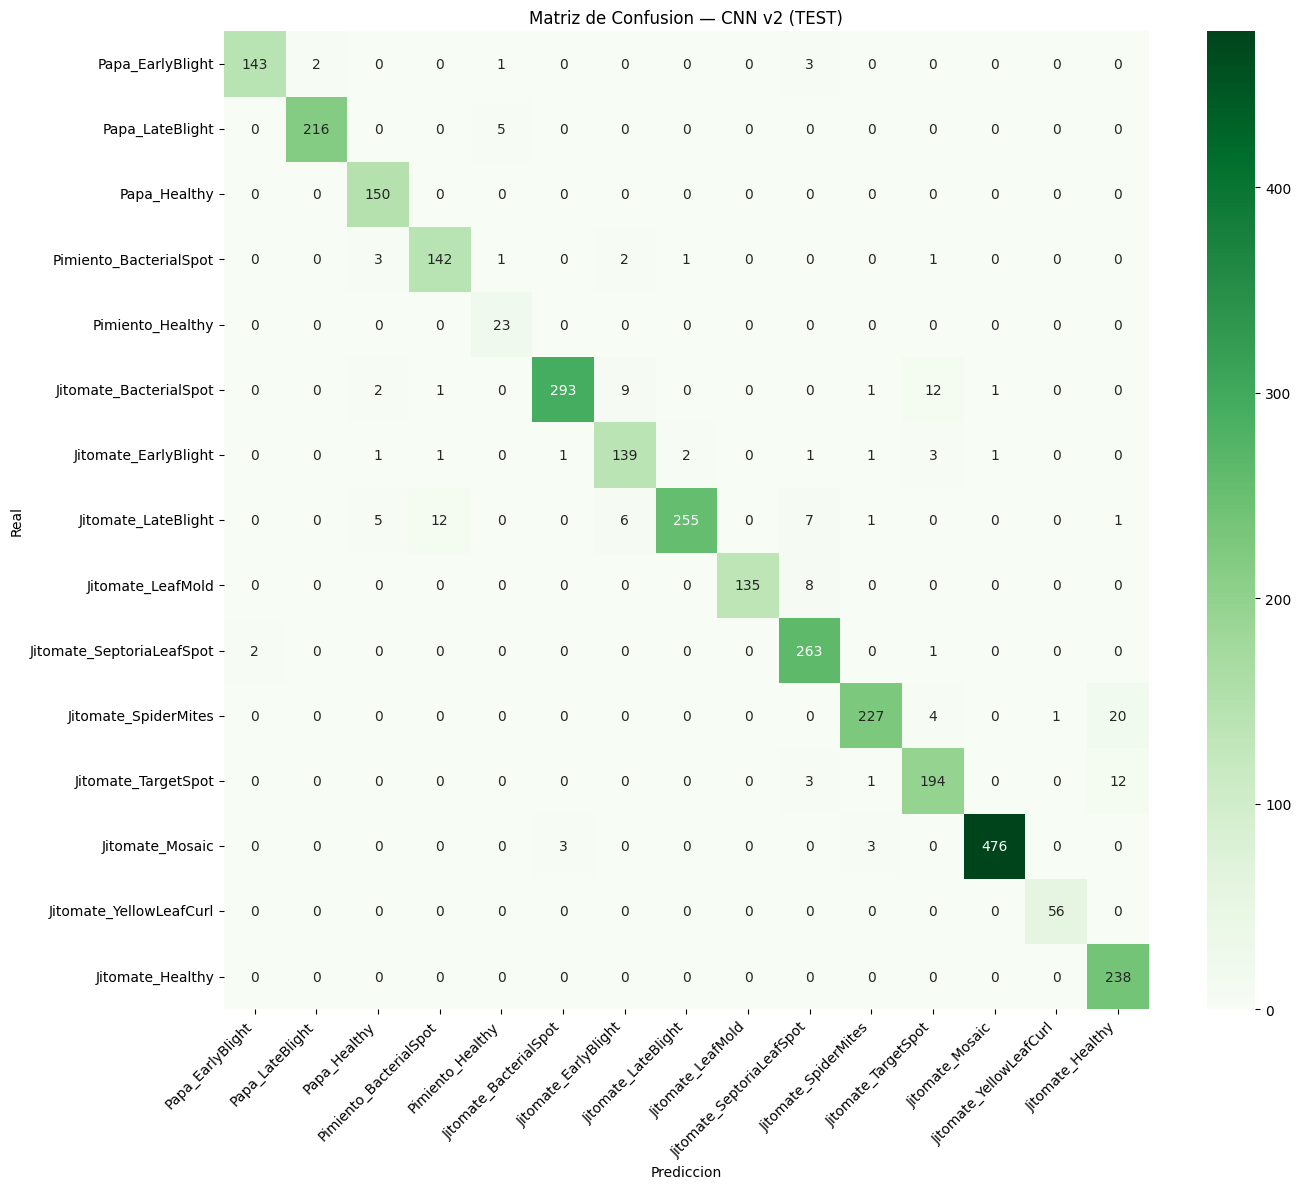

=== REPORTE FINAL — CNN v2 (TEST) ===
                           precision    recall  f1-score   support

         Papa_EarlyBlight       0.99      0.96      0.97       149
          Papa_LateBlight       0.99      0.98      0.98       221
             Papa_Healthy       0.93      1.00      0.96       150
   Pimiento_BacterialSpot       0.91      0.95      0.93       150
         Pimiento_Healthy       0.77      1.00      0.87        23
   Jitomate_BacterialSpot       0.99      0.92      0.95       319
     Jitomate_EarlyBlight       0.89      0.93      0.91       150
      Jitomate_LateBlight       0.99      0.89      0.94       287
        Jitomate_LeafMold       1.00      0.94      0.97       143
Jitomate_SeptoriaLeafSpot       0.92      0.99      0.95       266
     Jitomate_SpiderMites       0.97      0.90      0.93       252
      Jitomate_TargetSpot       0.90      0.92      0.91       210
          Jitomate_Mosaic       1.00      0.99      0.99       482
  Jitomate_YellowLeafCu

In [ ]:
# ============================================================
# EVALUACION FINAL SOBRE TEST
# ============================================================
y_pred_v2  = np.argmax(modelo_v2.predict(X_test, verbose=0), axis=1)
y_true_test = np.argmax(y_test, axis=1)

cm_test = confusion_matrix(y_true_test, y_pred_v2)
plt.figure(figsize=(14, 12))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens',
            xticklabels=NOMBRES_CLASES, yticklabels=NOMBRES_CLASES)
plt.title('Matriz de Confusion — CNN v2 (TEST)')
plt.xlabel('Prediccion'); plt.ylabel('Real')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(SAVE_PATH + 'confusion_matrix_v2_test.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== REPORTE FINAL — CNN v2 (TEST) ===')
print(classification_report(y_true_test, y_pred_v2, target_names=NOMBRES_CLASES))
acc_test = accuracy_score(y_true_test, y_pred_v2)
print(f'Accuracy final en TEST: {acc_test*100:.2f}%')

In [ ]:
# ============================================================
# EXPORTAR MODELO FINAL (.h5 y metadata .pkl para app)
# ============================================================
import pickle

modelo_v2.save(MODEL_PATH + 'cnn_final.h5')
print(f'cnn_final.h5  ->  {MODEL_PATH}')

metadata = {
    'nombres_clases': NOMBRES_CLASES,
    'img_size': IMG_SIZE,
    'num_classes': NUM_CLASSES,
    'accuracy_val':  float(acc_v2_eval),
    'accuracy_test': float(acc_test),
    'version': 'v2'
}
with open(MODEL_PATH + 'cnn_metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)
print(f'cnn_metadata.pkl  ->  {MODEL_PATH}')

print('\n=== RESUMEN FINAL ===')
print(f'Val  accuracy: {acc_v2_eval*100:.2f}%')
print(f'Test accuracy: {acc_test*100:.2f}%')
print('Archivos: cnn_final.h5 | best_cnn_v2.h5 | cnn_metadata.pkl')

cnn_final.h5  ->  /content/drive/MyDrive/RootKit/models/
cnn_metadata.pkl  ->  /content/drive/MyDrive/RootKit/models/

=== RESUMEN FINAL ===
Val  accuracy: 94.96%
Test accuracy: 95.28%
Archivos: cnn_final.h5 | best_cnn_v2.h5 | cnn_metadata.pkl


## CNN v3 — Overfitting Corregido

Tercera version enfocada en estabilizar el entrenamiento y reducir el overfitting detectado en v2, manteniendo la misma profundidad de arquitectura pero con hiperparametros mas conservadores.

**Implementa:**
- Misma arquitectura que v2: 4 bloques Conv2D + BatchNormalization
- Dropout aumentado a 0.5 en capa densa principal
- Learning rate reducido a 3e-4 para convergencia mas estable
- Data augmentation mas suave: rotation=15, sin shear
- ReduceLROnPlateau con patience=4, EarlyStopping con patience=8

**Resultado:** 97.58% de accuracy en validacion

**Diferencias con v1 y v2:**
- Mismo numero de capas que v2 pero Dropout mas alto (0.5 vs 0.4)
- Learning rate mas bajo (3e-4 vs 1e-3 de v2), entrenamiento mas estable
- Augmentation mas suave que v2, menos distorsiones
- Curvas de validacion mas estables que v2, menos oscilaciones
- Mejor accuracy final que v1 (+6.11%) y que v2 (+2.62%)

In [7]:
# ============================================================
# CNN v3 — corrige el overfitting de v2
# ============================================================
def construir_cnn_v3(input_shape=(128, 128, 3), num_classes=NUM_CLASSES, dropout=0.5):
    model = Sequential(name='CNN_PlantVillage_v3')

    # Bloque 1
    model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))

    # Bloque 2
    model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))

    # Bloque 3
    model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))

    # Bloque 4
    model.add(Conv2D(256, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))

    model.add(Flatten())
    model.add(Dense(512, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(dropout))       # subido a 0.5
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(dropout * 0.6))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),  # lr mas bajo
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [8]:
# Data augmentation mas suave
datagen_v3 = ImageDataGenerator(
    rotation_range=15,        # antes 20
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
    # sin shear — causaba distorsiones fuertes
)
datagen_v3.fit(X_train)

In [9]:
callbacks_v3 = [
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,           # un poco mas de paciencia
        min_lr=1e-6,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=8,
        min_delta=0.001,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=MODEL_PATH + 'best_cnn_v3.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

modelo_v3 = construir_cnn_v3(input_shape=(*IMG_SIZE, 3), num_classes=NUM_CLASSES)

historia_v3 = modelo_v3.fit(
    datagen_v3.flow(X_train, y_train, batch_size=BATCH_SIZE),
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    epochs=50,
    validation_data=(X_val, y_val),
    callbacks=callbacks_v3,
    verbose=1
)

print(f'\n v3 completado en {len(historia_v3.history["accuracy"])} epochs')

Epoch 1/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5050 - loss: 1.6623
Epoch 1: val_accuracy improved from None to 0.18152, saving model to /content/drive/MyDrive/RootKit/models/best_cnn_v3.h5



Epoch 1: finished saving model to /content/drive/MyDrive/RootKit/models/best_cnn_v3.h5
451/451 ━━━━━━━━━━━━━━━━━━━━ 1228s 3s/step - accuracy: 0.6149 - loss: 1.2190 - val_accuracy: 0.1815 - val_loss: 5.3978 - learning_rate: 3.0000e-04
Epoch 2/50
  1/451 ━━━━━━━━━━━━━━━━━━━━ 15:36 2s/step - accuracy: 0.7812 - loss: 0.7456
Epoch 2: val_accuracy did not improve from 0.18152
451/451 ━━━━━━━━━━━━━━━━━━━━ 84s 182ms/step - accuracy: 0.7812 - loss: 0.7456 - val_accuracy: 0.1812 - val_loss: 5.4070 - learning_rate: 3.0000e-04
Epoch 3/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7592 - loss: 0.7376
Epoch 3: val_accuracy improved from 0.18152 to 0.85820, saving model to /content/drive/MyDrive/RootKit/models/best_cnn_v3.h5



Epoch 3: finished saving model to /content/drive/MyDrive/RootKit/models/best_cnn_v3.h5
451/451 ━━━━━━━━━━━━━━━━━━━━ 1193s 3s/step - accuracy: 0.7723 - loss: 0.6927 - val_accuracy: 0.8582 - val_loss: 0.4132 - learning_rate: 3.0000e-04
Epoch 4/50
  1/451 ━━━━━━━━━━━━━━━━━━━━ 14:59 2s/step - accuracy: 0.8438 - loss: 0.5857
Epoch 4: val_accuracy improved from 0.85820 to 0.86014, saving model to /content/drive/MyDrive/RootKit/models/best_cnn_v3.h5



Epoch 4: finished saving model to /content/drive/MyDrive/RootKit/models/best_cnn_v3.h5
451/451 ━━━━━━━━━━━━━━━━━━━━ 55s 118ms/step - accuracy: 0.8438 - loss: 0.5857 - val_accuracy: 0.8601 - val_loss: 0.4131 - learning_rate: 3.0000e-04
Epoch 5/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8243 - loss: 0.5322
Epoch 5: val_accuracy did not improve from 0.86014
451/451 ━━━━━━━━━━━━━━━━━━━━ 1172s 3s/step - accuracy: 0.8295 - loss: 0.5140 - val_accuracy: 0.5930 - val_loss: 1.7070 - learning_rate: 3.0000e-04
Epoch 6/50
  1/451 ━━━━━━━━━━━━━━━━━━━━ 14:58 2s/step - accuracy: 0.8438 - loss: 0.4468
Epoch 6: val_accuracy did not improve from 0.86014
451/451 ━━━━━━━━━━━━━━━━━━━━ 50s 108ms/step - accuracy: 0.8438 - loss: 0.4468 - val_accuracy: 0.5963 - val_loss: 1.6840 - learning_rate: 3.0000e-04
Epoch 7/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8650 - loss: 0.4035
Epoch 7: val_accuracy improved from 0.86014 to 0.87145, saving model to /content/drive/MyDrive/RootKit/models


Epoch 7: finished saving model to /content/drive/MyDrive/RootKit/models/best_cnn_v3.h5
451/451 ━━━━━━━━━━━━━━━━━━━━ 1201s 3s/step - accuracy: 0.8725 - loss: 0.3930 - val_accuracy: 0.8714 - val_loss: 0.3599 - learning_rate: 3.0000e-04
Epoch 8/50
  1/451 ━━━━━━━━━━━━━━━━━━━━ 22:52 3s/step - accuracy: 0.9375 - loss: 0.2520
Epoch 8: val_accuracy improved from 0.87145 to 0.87274, saving model to /content/drive/MyDrive/RootKit/models/best_cnn_v3.h5


...


Epoch 12: finished saving model to /content/drive/MyDrive/RootKit/models/best_cnn_v3.h5
451/451 ━━━━━━━━━━━━━━━━━━━━ 57s 120ms/step - accuracy: 0.7812 - loss: 0.6331 - val_accuracy: 0.8815 - val_loss: 0.3654 - learning_rate: 3.0000e-04
Epoch 13/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9268 - loss: 0.2075
Epoch 13: val_accuracy improved from 0.88146 to 0.94251, saving model to /content/drive/MyDrive/RootKit/models/best_cnn_v3.h5



Epoch 13: finished saving model to /content/drive/MyDrive/RootKit/models/best_cnn_v3.h5
451/451 ━━━━━━━━━━━━━━━━━━━━ 1223s 3s/step - accuracy: 0.9315 - loss: 0.2009 - val_accuracy: 0.9425 - val_loss: 0.1739 - learning_rate: 1.5000e-04
Epoch 14/50
  1/451 ━━━━━━━━━━━━━━━━━━━━ 26:13 3s/step - accuracy: 0.9062 - loss: 0.1179
Epoch 14: val_accuracy improved from 0.94251 to 0.94348, saving model to /content/drive/MyDrive/RootKit/models/best_cnn_v3.h5



Epoch 14: finished saving model to /content/drive/MyDrive/RootKit/models/best_cnn_v3.h5
451/451 ━━━━━━━━━━━━━━━━━━━━ 87s 186ms/step - accuracy: 0.9062 - loss: 0.1179 - val_accuracy: 0.9435 - val_loss: 0.1704 - learning_rate: 1.5000e-04
Epoch 15/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9393 - loss: 0.1775
Epoch 15: val_accuracy did not improve from 0.94348
451/451 ━━━━━━━━━━━━━━━━━━━━ 1203s 3s/step - accuracy: 0.9393 - loss: 0.1722 - val_accuracy: 0.7555 - val_loss: 1.8338 - learning_rate: 1.5000e-04
Epoch 16/50
  1/451 ━━━━━━━━━━━━━━━━━━━━ 14:57 2s/step - accuracy: 0.9375 - loss: 0.1246
Epoch 16: val_accuracy did not improve from 0.94348
451/451 ━━━━━━━━━━━━━━━━━━━━ 84s 182ms/step - accuracy: 0.9375 - loss: 0.1246 - val_accuracy: 0.7452 - val_loss: 1.9498 - learning_rate: 1.5000e-04
Epoch 17/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9452 - loss: 0.1634
Epoch 17: val_accuracy improved from 0.94348 to 0.96286, saving model to /content/drive/MyDrive/RootKit


Epoch 17: finished saving model to /content/drive/MyDrive/RootKit/models/best_cnn_v3.h5
451/451 ━━━━━━━━━━━━━━━━━━━━ 1218s 3s/step - accuracy: 0.9449 - loss: 0.1650 - val_accuracy: 0.9629 - val_loss: 0.1125 - learning_rate: 1.5000e-04
Epoch 18/50
  1/451 ━━━━━━━━━━━━━━━━━━━━ 17:15 2s/step - accuracy: 0.8750 - loss: 0.4585
Epoch 18: val_accuracy did not improve from 0.96286
451/451 ━━━━━━━━━━━━━━━━━━━━ 59s 126ms/step - accuracy: 0.8750 - loss: 0.4585 - val_accuracy: 0.9619 - val_loss: 0.1140 - learning_rate: 1.5000e-04
Epoch 19/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9505 - loss: 0.1413
Epoch 19: val_accuracy improved from 0.96286 to 0.97578, saving model to /content/drive/MyDrive/RootKit/models/best_cnn_v3.h5



Epoch 19: finished saving model to /content/drive/MyDrive/RootKit/models/best_cnn_v3.h5
451/451 ━━━━━━━━━━━━━━━━━━━━ 1171s 3s/step - accuracy: 0.9521 - loss: 0.1432 - val_accuracy: 0.9758 - val_loss: 0.0807 - learning_rate: 1.5000e-04
Epoch 20/50
  1/451 ━━━━━━━━━━━━━━━━━━━━ 15:46 2s/step - accuracy: 0.9062 - loss: 0.1927
Epoch 20: val_accuracy did not improve from 0.97578
451/451 ━━━━━━━━━━━━━━━━━━━━ 84s 182ms/step - accuracy: 0.9062 - loss: 0.1927 - val_accuracy: 0.9748 - val_loss: 0.0839 - learning_rate: 1.5000e-04
Epoch 21/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9526 - loss: 0.1395
Epoch 21: val_accuracy did not improve from 0.97578
451/451 ━━━━━━━━━━━━━━━━━━━━ 1139s 3s/step - accuracy: 0.9512 - loss: 0.1400 - val_accuracy: 0.8094 - val_loss: 1.1399 - learning_rate: 1.5000e-04
Epoch 22/50
  1/451 ━━━━━━━━━━━━━━━━━━━━ 24:23 3s/step - accuracy: 0.9375 - loss: 0.1123
Epoch 22: val_accuracy did not improve from 0.97578
451/451 ━━━━━━━━━━━━━━━━━━━━ 52s 108ms/step - acc

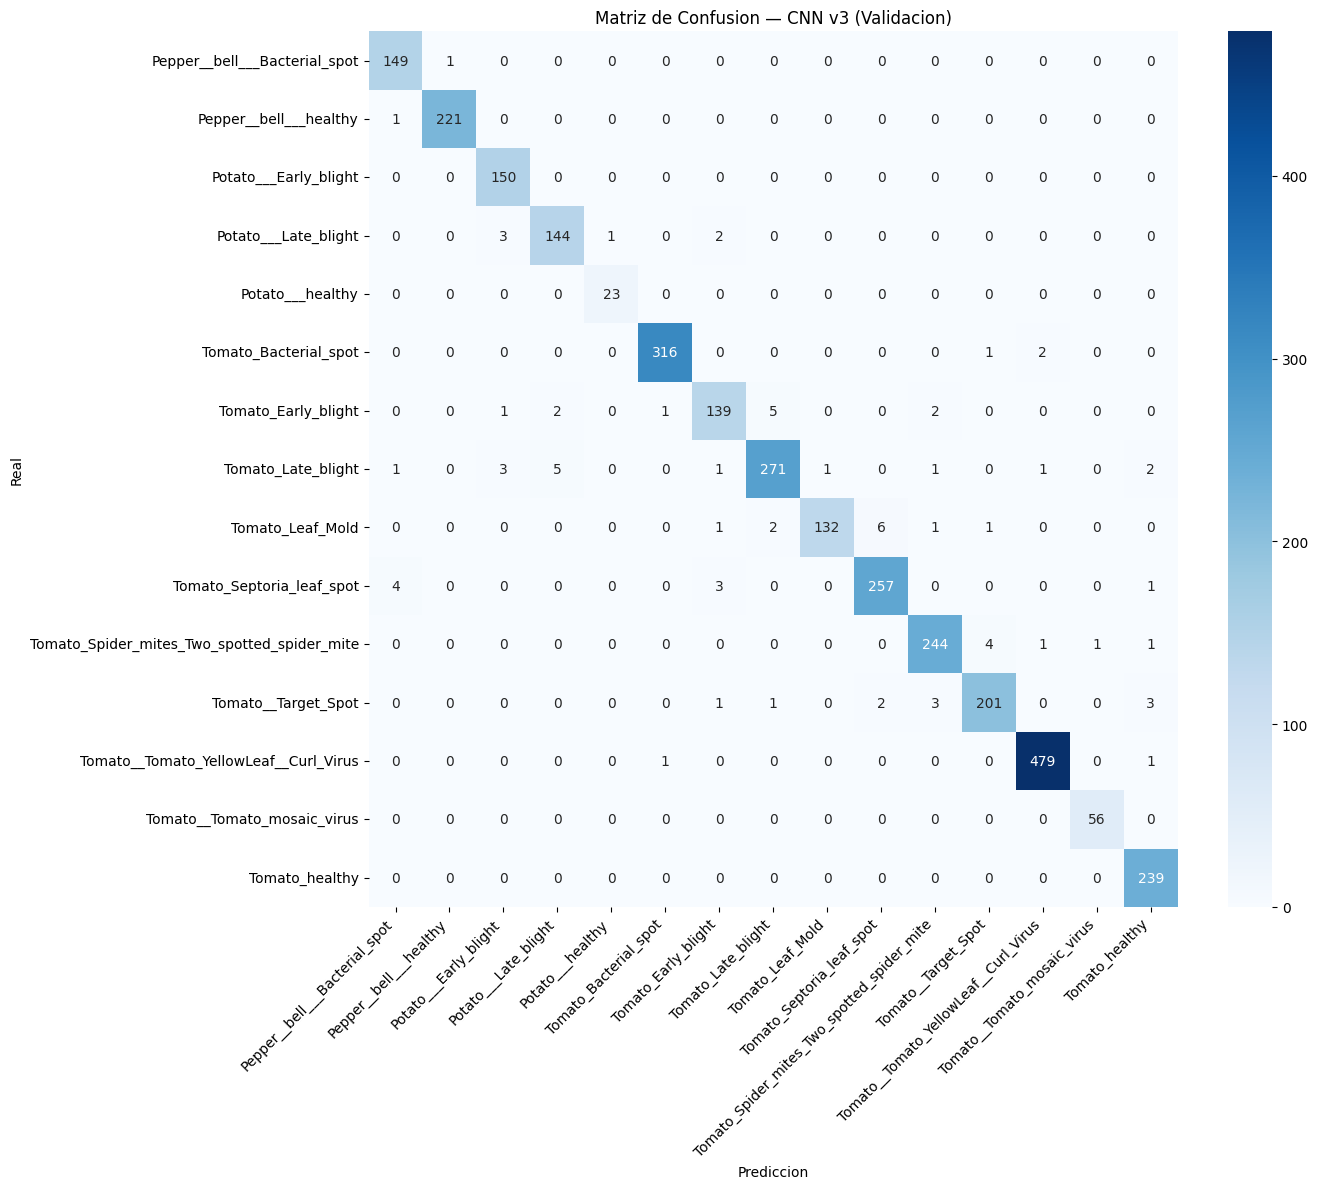

Matriz guardada en: /content/drive/MyDrive/RootKit/procesado/confusion_matrix_v3.png


In [10]:
# ============================================================
# MATRIZ DE CONFUSION CNN v3 — set de validacion
# ============================================================
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

y_pred_v3  = np.argmax(modelo_v3.predict(X_val, verbose=0), axis=1)
y_true_val = np.argmax(y_val, axis=1)

cm_v3 = confusion_matrix(y_true_val, y_pred_v3)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm_v3,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=NOMBRES_CLASES,
    yticklabels=NOMBRES_CLASES
)
plt.title('Matriz de Confusion — CNN v3 (Validacion)')
plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(SAVE_PATH + 'confusion_matrix_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Matriz guardada en: {SAVE_PATH}confusion_matrix_v3.png')

In [12]:
# ============================================================
# DEFINIR graficar_historia (necesaria si se perdio la sesion)
# ============================================================
import matplotlib.pyplot as plt

def graficar_historia(historia, titulo='CNN', guardar_en=None):
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(historia.history['accuracy']) + 1)

    axs[0].plot(epochs, historia.history['accuracy'],     'b-o', label='Train')
    axs[0].plot(epochs, historia.history['val_accuracy'], 'r-o', label='Validacion')
    axs[0].set_title(f'{titulo} — Accuracy')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Accuracy')
    axs[0].legend()
    axs[0].grid(True)

    axs[1].plot(epochs, historia.history['loss'],     'b-o', label='Train')
    axs[1].plot(epochs, historia.history['val_loss'], 'r-o', label='Validacion')
    axs[1].set_title(f'{titulo} — Loss')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Loss')
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    if guardar_en:
        plt.savefig(guardar_en, dpi=150, bbox_inches='tight')
        print(f'Guardado: {guardar_en}')
    plt.show()

=== COMPARACION FINAL ===
CNN v3  ->  97.58%
Guardado: /content/drive/MyDrive/RootKit/procesado/curvas_cnn_v3.png


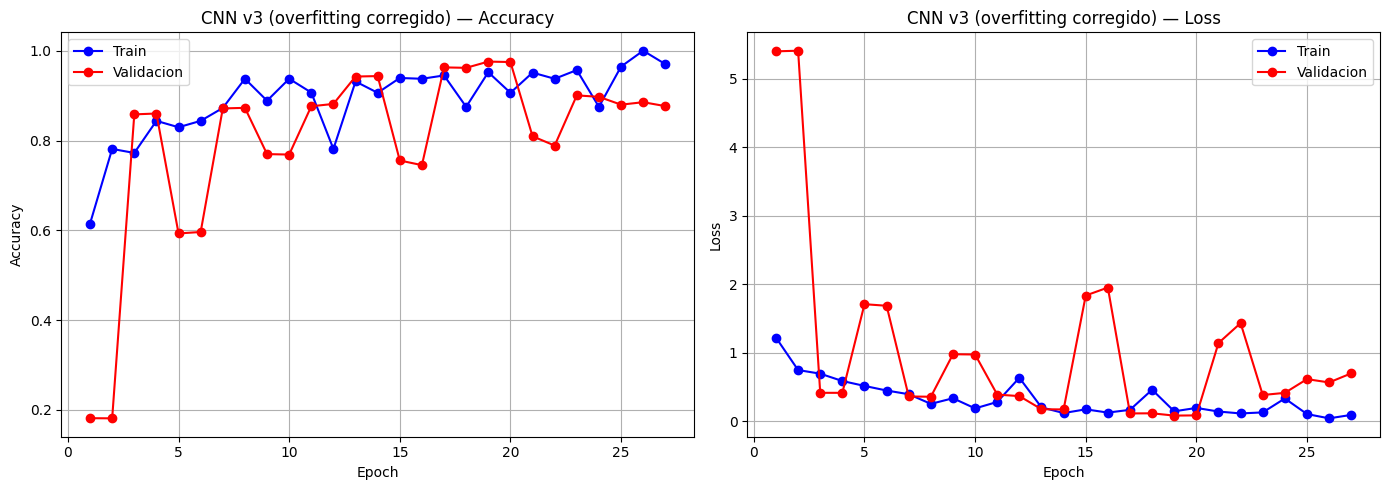

In [13]:
# Comparacion v1 vs v2 vs v3
#_, acc_v1_eval = modelo_v1.evaluate(X_val, y_val, verbose=0)
#_, acc_v2_eval = modelo_v2.evaluate(X_val, y_val, verbose=0)
_, acc_v3_eval = modelo_v3.evaluate(X_val, y_val, verbose=0)

print('=== COMPARACION FINAL ===')
#print(f'CNN v1  ->  {acc_v1_eval*100:.2f}%')
#print(f'CNN v2  ->  {acc_v2_eval*100:.2f}%')
print(f'CNN v3  ->  {acc_v3_eval*100:.2f}%')

graficar_historia(historia_v3,
                  titulo='CNN v3 (overfitting corregido)',
                  guardar_en=SAVE_PATH + 'curvas_cnn_v3.png')

In [14]:
import os

archivos = os.listdir(MODEL_PATH)
print(f'Archivos en {MODEL_PATH}:')
for archivo in sorted(archivos):
    ruta = MODEL_PATH + archivo
    tam  = os.path.getsize(ruta) / (1024 * 1024)  # en MB
    print(f'  {archivo}  —  {tam:.1f} MB')

Archivos en /content/drive/MyDrive/RootKit/models/:
  best_cnn_v1.h5  —  97.2 MB
  best_cnn_v2.h5  —  102.1 MB
  best_cnn_v3.h5  —  102.1 MB
  clustering_kmeans.pkl  —  0.0 MB
  clustering_pca.pkl  —  0.0 MB
  clustering_scaler.pkl  —  0.0 MB
  cnn_final.h5  —  102.1 MB
  cnn_metadata.pkl  —  0.0 MB
  cnn_v1.h5  —  97.2 MB
  regresion_severidad.pkl  —  149.9 MB
